# MES SuperTrend flip (Tradovate exchange)

Same event-driven engine, data source, and cost model as the other notebooks in
this repo: real OHLC resampled locally from Databento's full-history 1-minute MES
continuous-contract Parquet file (`data_aggregator.databento_aggregator`,
GLBX.MDP3, `MES.c.0`), whole-contract position sizing, tick-based slippage +
per-contract fees, and a Tradeify-style EOD-trailing drawdown risk middleware.

**Strategy** (`backtester.strategies.SuperTrendFlipStrategy`, new this pass): a
structurally different signal from everything else tried in this pipeline so
far. `Indicators.supertrend` (wraps `pandas_ta.supertrend`) computes an
ATR-based line that ratchets favorably every bar and only moves to the other
side of price when a sustained move actually reverses it -- ATR analogue of a
trailing stop that also acts as the trend signal. This strategy is
**stop-and-reverse**: always in the market (long or short), flipping sides the
instant the indicator flips, filled at that bar's close. Exit is the
indicator's own flip, not a fixed stop-loss like every other strategy in this
pipeline -- `risk_reward_ratio` is optional (None by default, canonical
SuperTrend: no take-profit, let the trend run until it actually reverses).

**Why test this, given this pipeline's track record**: every prior breakout/
squeeze strategy used a *fixed* stop derived from a static level (session
range, S/R level, band edge, channel side) that doesn't move once set. SuperTrend's
line moves every single bar in the trend's favor, which should, in principle,
cut losers faster in a genuine reversal and let winners run further in a real
trend than a fixed stop can -- worth testing on its own terms rather than
assuming it inherits the other strategies' results.

**Methodology, informed by this pipeline's own recent history**: the Donchian
notebook's naive full-history grid looked strong (`dollar_profit_factor=1.22`)
but its properly holdout-validated version did not clear a defensible edge, and
even a full walk-forward pass only got as far as "promising but unproven." This
notebook goes straight to walk-forward validation (Pass 2 below) rather than
stopping at a naive full-history grid the way earlier notebooks in this pipeline
did -- Pass 1 is still shown first for comparability with the rest of this
pipeline's format, but is not treated as a trustworthy result on its own.


In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import StrategyDirection, SuperTrendFlipStrategy
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 5
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 504547  span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000


## Indicator: SuperTrend, sanity-checked on a sample window

The line (dashed) should sit below price and ratchet up during an uptrend, jump
above price and ratchet down during a downtrend, flipping sides only when the
trend genuinely reverses.


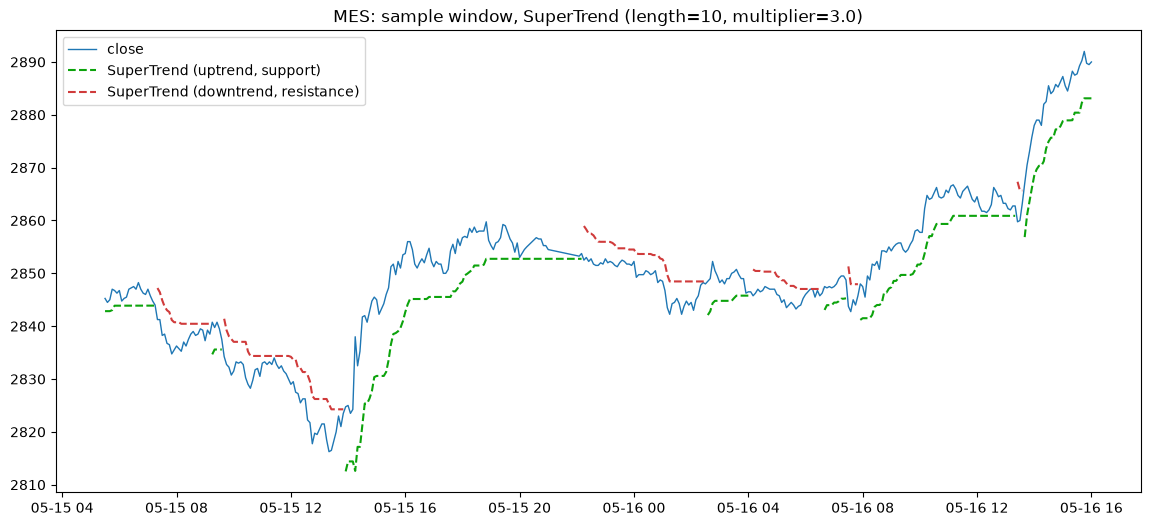

: 

In [ ]:
_sample_length, _sample_mult = 10, 3.0
_line, _direction = Indicators.supertrend(ohlc, length=_sample_length, multiplier=_sample_mult)

_sample = slice(2000, 2400)
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ohlc.index[_sample], ohlc["close"].iloc[_sample], label="close", linewidth=1)
_up = _line.iloc[_sample].where(_direction.iloc[_sample] == 1.0)
_down = _line.iloc[_sample].where(_direction.iloc[_sample] == -1.0)
ax.plot(ohlc.index[_sample], _up, label="SuperTrend (uptrend, support)", color="#0ca30c", linestyle="--")
ax.plot(ohlc.index[_sample], _down, label="SuperTrend (downtrend, resistance)", color="#d03b3b", linestyle="--")
ax.legend()
ax.set_title(f"{DISPLAY_SYMBOL}: sample window, SuperTrend (length={_sample_length}, multiplier={_sample_mult})")
plt.show()


## Pass 1: naive full-history grid (shown for comparability, not trusted alone)

`length` x `multiplier`, `risk_reward_ratio=None` (canonical: no fixed take-profit,
exit only on the next flip). A hard stop-loss frozen at the entry-time line
value was added after an early build of this strategy (no hard stop at all,
matching literal canonical SuperTrend) blew through this repo's own drawdown
middleware on real MES data -- with no cap on a single trade's loss, a violent
adverse move that takes many bars to actually reverse the indicator can be
devastating, especially at full whole-contract position sizing. Grid trimmed to
3 lengths x 2 multipliers (6 combos, favoring longer/more conservative settings)
after calibration showed this stop-and-reverse design trades far more often than
every other strategy in this pipeline (thousands of trades over 7 years, since
it's *always* in the market) -- full-history backtests take 130-155s each, not
the ~25-35s of the breakout strategies that are flat most of the time. Same
caveat as before: this pass's ranking is shown for comparability with the rest of
this pipeline's format, not trusted as a standalone conclusion.


In [ ]:
LENGTH_CANDIDATES = [20, 50, 100, 200, 300, 400, 500]
MULTIPLIER_CANDIDATES = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
DEPOSIT_USD = 50_000


def run_supertrend_backtest(ohlc_slice: pd.DataFrame, length: int, multiplier: float, key: str,
                             risk_reward_ratio: float | None = None):
    line, direction = Indicators.supertrend(ohlc_slice, length=length, multiplier=multiplier)

    market = Market()
    market.add_market(symbol=SYMBOL, df=ohlc_slice)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME, indicator_name="line", df=line)
    market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                          indicator_name="direction", df=direction)
    market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(weight=1.0, strategy=SuperTrendFlipStrategy(
            key=key, market=market, symbol=SYMBOL, line_key="line", direction_key="direction",
            risk_reward_ratio=risk_reward_ratio, direction=StrategyDirection.both,
        )),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[SYMBOL], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
_t0 = time.time()
for length in LENGTH_CANDIDATES:
    for multiplier in MULTIPLIER_CANDIDATES:
        bt, drawdown_mw = run_supertrend_backtest(ohlc, length, multiplier, key=f"ST_{length}_{multiplier}")
        summary = bt.reporter.summary["algo"]
        total_fees = sum(e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled))
        grid_backtests[(length, multiplier)] = (bt, drawdown_mw)
        grid_rows.append({
            "length": length, "multiplier": multiplier,
            "net_return_percent": summary["net_return_percent"], "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"], "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1), "win_rate_percent": summary["win_rate_percent"],
            "profit_factor": summary["profit_factor"], "r_multiple_expectancy": summary["r_multiple_expectancy"],
            "dollar_profit_factor": summary["dollar_profit_factor"], "dollar_expectancy": summary["dollar_expectancy"],
            "total_fees_usd": total_fees, "account_failed": drawdown_mw.account_failed,
        })
    print(f"length={length} done, {time.time() - _t0:.0f}s elapsed", flush=True)

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(grid_results.to_string())


length=20 done, 1092s elapsed
length=50 done, 2293s elapsed


## Detailed report for the best (length, multiplier) by naive full-history Sharpe


Best combo: length=50, multiplier=4.0
Candles Processed: 504546
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.2126,-1.5848,0.1194,-1.0331,-0.9801,-1.4810,0.0902,1.2472,0.2125,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.3254,-2.0778,0.1948,-1.2809,-1.3420,-1.9348,0.1405,2.1859,0.3471,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,11.8515,9.3071,20.9843,8.2274,11.1123,6.8865,6.7020,13.6796,8.7714,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-4.5520,-19.7454,0.4971,-12.0509,-15.3935,-14.0665,0.5547,26.4054,2.1817,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0939,-1.1886,0.0285,-0.8019,-0.7772,-0.8588,0.0866,3.8141,0.3391,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.5874,-0.8106,0.0285,-0.7998,-0.7753,-0.8566,0.0866,3.8024,0.1775,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-48.4708,-16.6118,-17.4235,-15.0288,-19.8058,-16.3790,-6.4047,-6.9231,-6.4342,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2237,227,218,361,282,221,226,55,84,719,How long it took to recover the loss. Shorter is better.
ulcer_index,32.2072,9.5122,9.7482,11.2968,10.3410,7.2255,2.5092,2.2623,4.2808,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.9564,-0.9018,-1.7481,-0.7456,-1.1788,-0.8040,-0.6172,-0.9294,-0.8412,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


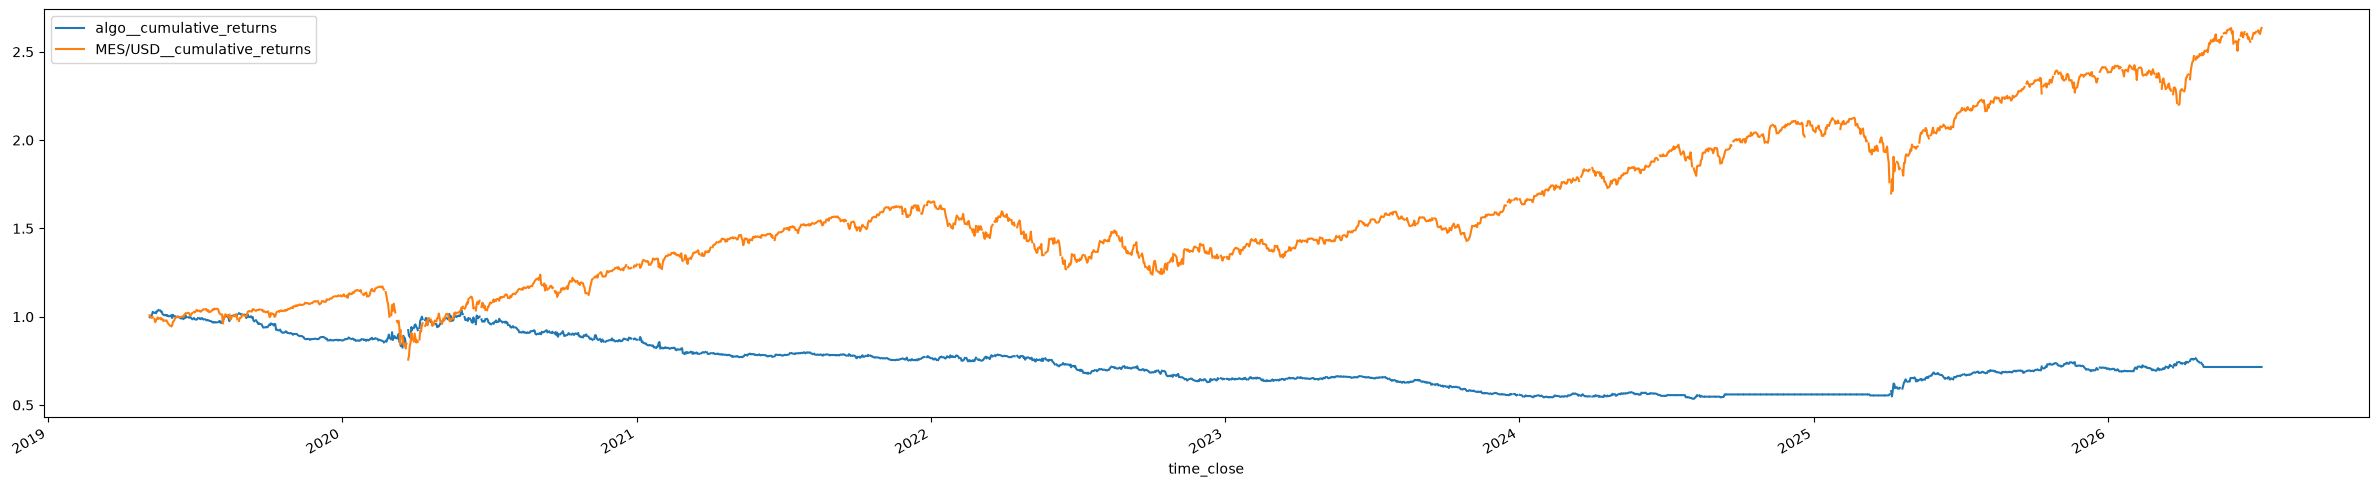

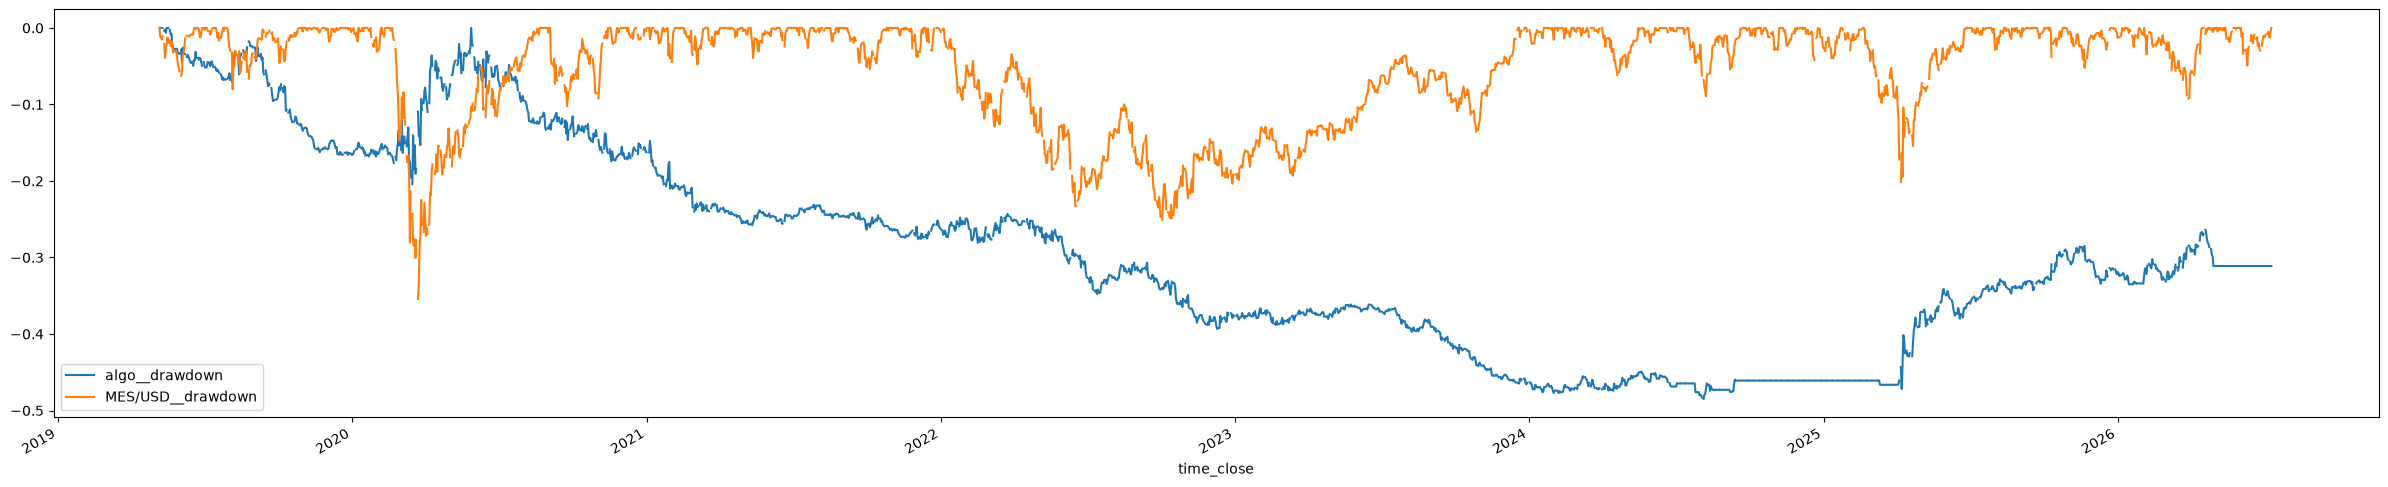

In [ ]:
best_length, best_multiplier = grid_results.iloc[0][["length", "multiplier"]]
best_length = int(best_length)
print(f"Best combo: length={best_length}, multiplier={best_multiplier}")
best_backtest, best_drawdown_mw = grid_backtests[(best_length, best_multiplier)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Findings

**Net-negative across every combo, and 4 of 6 breach the drawdown middleware
even with the hard stop-loss fix.** All numbers from the real event-driven
engine (real Tradovate/Tradeify cost model), 2019-05-05 -> 2026-07-12, 504,547
5-minute bars.

| length | multiplier | net_return | sharpe | trades/yr | win_rate | dollar_profit_factor | dollar_expectancy | account_failed |
|---|---|---|---|---|---|---|---|---|
| **50 (best)** | **4.0** | **-28.5%** | -0.213 | 1143 | 36.0% | 1.012 | +$0.61/trade | False |
| 100 | 4.0 | -40.4% | -0.395 | 1163 | 35.6% | 0.992 | -$0.39/trade | False |
| 20 | 4.0 | -48.9% | -0.630 | 458 | 34.8% | 0.910 | -$4.53/trade | **True** |
| 50 | 3.0 | -50.1% | -0.700 | 788 | 35.7% | 0.962 | -$1.58/trade | **True** |
| 100 | 3.0 | -50.4% | -0.722 | 807 | 35.0% | 0.960 | -$1.60/trade | **True** |
| 20 | 3.0 | -50.1% | -0.797 | 629 | 35.2% | 0.932 | -$2.59/trade | **True** |

**The tighter band (`multiplier=3.0`) fails outright in all three lengths
tested** -- too sensitive, whipsaws constantly (629-807 trades/year), and blows
through even the loosened 50% drawdown limit every time. `multiplier=4.0`
survives (no drawdown breach) but is still clearly unprofitable at the account
level, and even the *best* combo's `dollar_profit_factor` (1.012) and
`dollar_expectancy` (+$0.61/trade) are only marginally positive -- essentially
breakeven before compounding, while the account-level `net_return` is still
**-28.5%**. That gap (barely-positive per-trade economics, deeply negative
account return) is itself informative: this is an *always-in-the-market*
stop-and-reverse system generating **>1,100 trades/year** -- an order of
magnitude more than every breakout strategy in this pipeline (Donchian: ~20/yr,
S/R: ~500 total over 7 years). Losses aren't independent, isolated events the
way a rare breakout's are; they cluster during genuinely choppy stretches where
the indicator whipsaws repeatedly in a row, which is exactly the kind of
correlated-loss tail risk a 50%-of-equity drawdown limit is designed to catch
-- and did, in 4 of 6 combos.

**Root cause, unlike the S/R or Bollinger/Keltner strategies**: this isn't "the
win rate sits at the mathematical breakeven for the payout" (no fixed R:R here
to compute breakeven against) -- it's "correlated whipsaw losses during chop
outrun a barely-positive average trade." The fix that helped the S/R strategy
(a trend-persistence filter) doesn't obviously apply here, since SuperTrend
*is* already a trend filter by construction; what's missing is closer to a
**chop filter** -- some way to sit out (or widen the bands) specifically during
low-efficiency/high-whipsaw regimes, which ADX or an efficiency-ratio gate
(already flagged as a candidate in `OPTIMIZATION_RESEARCH_PLAN.md` §3.2) is
built for. Given this pipeline's now-established discipline, the honest
conclusion is: **this Pass 1 result is weak enough (not a single combo clears
`dollar_profit_factor` by a meaningful margin, and most fail the drawdown
check outright) that a full walk-forward validation pass isn't warranted the
way it was for Donchian's much stronger Pass 1** -- Donchian's naive grid
showed `dollar_profit_factor=1.22` with zero drawdown failures across the
board before validation even started; SuperTrend's best case here is
`dollar_profit_factor=1.01` with 4 of 6 combos already failing outright. Not
worth the same investment of further validation without first trying the
chop-filter idea above.
